## 1 · Imports & configuration

In [2]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(patchwork)   # combiner les plots ggplot2

source("functions_linear.R")

DATASET_PATH <- "/Volumes/My Passport/NEWMOB/clean_dataset.csv"
FPS          <- 30
COLOR_A      <- "#2E86AB"
COLOR_B      <- "#E84855"

theme_set(theme_bw(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(size = 12)))

installation de la dépendance ‘insight’





Les packages binaires téléchargés sont dans
	/var/folders/y0/0nrj3m412p978185q3d2503sr02q24/T//Rtmpefhpt4/downloaded_packages
✔ Fonctions R chargées : run_linear, run_mixed_linear_panel


## 2 · Chargement du dataset

In [3]:
df_raw <- read.csv(DATASET_PATH, stringsAsFactors = FALSE)
cat(sprintf("Dataset brut : %s lignes x %d colonnes\n",
            format(nrow(df_raw), big.mark = ","), ncol(df_raw)))
cat(sprintf("Trajets      : %d\n", n_distinct(df_raw$source)))
head(df_raw, 4)

Dataset brut : 346,426 lignes x 80 colonnes
Trajets      : 25


,source,frame,speed_kmh,gyrz_deg_s,n_vru_total,n_pedestrians,n_cyclists,n_escooters,prop_vru_pedestrian,prop_vru_cyclist,⋯,mean_ttc_min_s,mean_drac_max_ms2,mean_reaction_time_s,mean_encounter_duration_s,mean_simultaneous_vrus,pct_unknown_interaction,pct_group_size_solo,pct_group_size_pair,pct_group_size_group_3plus,pct_group_size_unknown
,<chr>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
2,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
3,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA
4,332t_2023-04-26 12_05_55_332t_21_27_22_15,205,11.76523,1.88503,1,1,0,0,1,0,⋯,2.548,3.099,NA,2.567,8.148,0,NA,NA,NA,NA


## 3 · Réduction à 1 Hz

Le dataset est échantillonné à 30 FPS. On regroupe par **seconde** (`second = frame %/% 30`) :

In [4]:
df_1hz <- df_raw %>%
  mutate(second = frame %/% FPS) %>%
  group_by(source, second) %>%
  summarise(
    speed_kmh                    = mean(speed_kmh,                        na.rm = TRUE),
    rider_id                     = first(rider_id),
    n_pedestrians                = median(n_pedestrians,                      na.rm = TRUE),
    n_cyclists                   = median(n_cyclists,                         na.rm = TRUE),
    road_width_perp_m            = mean(road_width_perp_m,                 na.rm = TRUE),
    environment_type             = first(environment_type), 
    hour                         = first(hour),
    day_of_week                  = first(day_of_week),
    day_name                     = first(day_name),
    environment_type             = first(environment_type),
    is_weekend                   = first(is_weekend),
    time_of_day                  = first(time_of_day),
    month                        = first(month),
    season                       = first(season),
    genre                        = first(genre),
    age                          = first(age),
    experience                   = first(experience),
    distance_km                  = first(distance_km),
    start_crossing               = max(start_crossing,                     na.rm = TRUE),
    prop_vru_cyclist             = max(prop_vru_cyclist,                   na.rm = TRUE), 
    prop_vru_pedestrian          = max(prop_vru_pedestrian,                na.rm = TRUE),
    prop_interaction_same_direction = max(prop_interaction_same_direction, na.rm = TRUE),
    prop_interaction_opposite_direction = max(prop_interaction_opposite_direction, na.rm = TRUE),
    prop_interaction_crossing = max(prop_interaction_crossing, na.rm = TRUE),

    # ── Nouvelles variables annotées ────────────────────────────────────────
    n_elderly                    = median(n_elderly,                          na.rm = TRUE),
    n_children                   = median(n_children,                         na.rm = TRUE),
    n_running                    = median(n_running,                          na.rm = TRUE),
    n_groups                     = median(n_groups,                           na.rm = TRUE),
    n_crossing                   = median(n_crossing,                         na.rm = TRUE),
    n_pedestrians_crossing       = median(n_pedestrians_crossing,             na.rm = TRUE),
    n_pedestrians_opposite       = median(n_pedestrians_opposite,             na.rm = TRUE),
    n_pedestrians_stationary     = median(n_pedestrians_stationary,           na.rm = TRUE),
    n_pedestrians_same_direction  = median(n_pedestrians_same_direction,      na.rm = TRUE),
    n_cyclists_crossing          = median(n_cyclists_crossing,                na.rm = TRUE),
    # ── Variables contextuelles (première valeur disponible) ────────────────
    WEATHER_LABEL                = first(na.omit(WEATHER_LABEL)),
    LIGHTING_LABEL               = first(na.omit(LIGHTING_LABEL)),
    SURFACE_CONDITION_LABEL      = first(na.omit(SURFACE_CONDITION_LABEL)),
    at_intersection              = first(na.omit(at_intersection)),
  ) %>%
  arrange(source, second) %>%
  group_by(source) %>%
  mutate(speed_kmh_t1 = lead(speed_kmh)) %>%
  ungroup()

cat(sprintf("Après réduction 1 Hz : %s secondes — %d trajets\n",
            format(nrow(df_1hz), big.mark = ","),
            n_distinct(df_1hz$source)))
summary(df_1hz)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by source and second.
ℹ Output is grouped by source.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(source, second))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


Après réduction 1 Hz : 1,271 secondes — 25 trajets


    source              second        speed_kmh        rider_id        
 Length:1271        Min.   :  0.0   Min.   : 2.018   Length:1271       
 Class :character   1st Qu.: 15.5   1st Qu.: 9.141   Class :character  
 Mode  :character   Median : 39.0   Median :11.918   Mode  :character  
                    Mean   : 52.5   Mean   :14.601                     
                    3rd Qu.: 77.0   3rd Qu.:20.422                     
                    Max.   :202.0   Max.   :33.850                     
                                                                       
 n_pedestrians      n_cyclists     road_width_perp_m  environment_type  
 Min.   : 0.000   Min.   :0.0000   Min.   :  0.0371   Length:1271       
 1st Qu.: 1.000   1st Qu.:0.0000   1st Qu.:  8.0910   Class :character  
 Median : 2.000   Median :0.0000   Median : 11.1179   Mode  :character  
 Mean   : 2.819   Mean   :0.1566   Mean   : 16.5803                     
 3rd Qu.: 4.000   3rd Qu.:0.0000   3rd Qu.: 22.6135        

## 4 · Variable dépendante : `speed_kmh_t1`

Observations totales : 1,246
  Vitesse moyenne : 14.65 km/h
  Vitesse médiane : 11.99 km/h
  Écart-type      : 7.66 km/h
  Min / Max       : 2.02 / 33.85 km/h


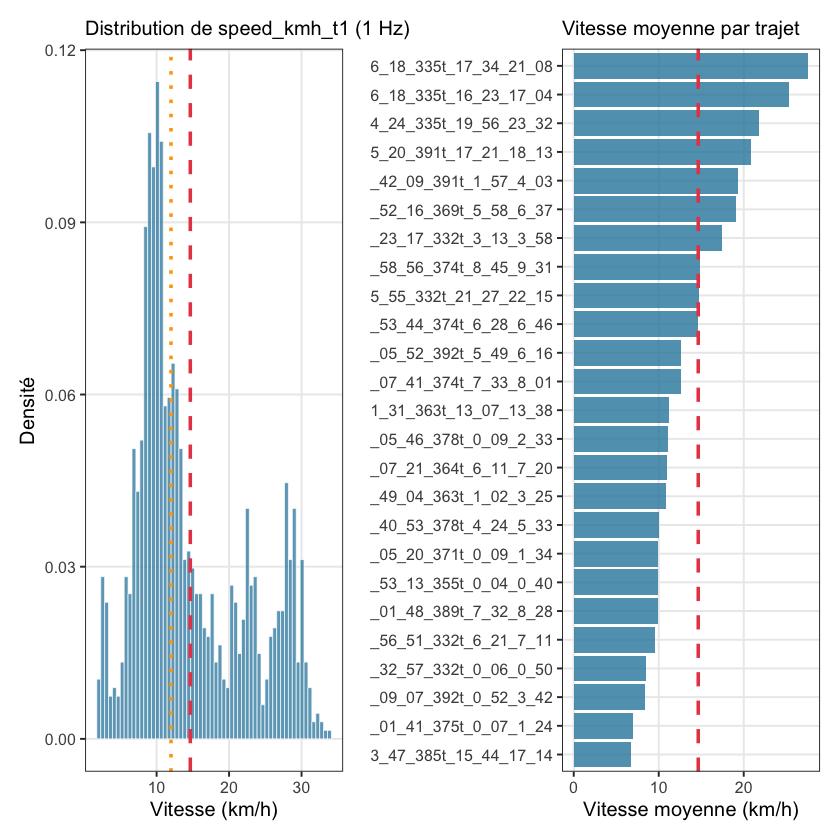

In [5]:
df_model <- df_1hz %>%
  filter(!is.na(speed_kmh_t1), !is.na(n_pedestrians), !is.na(road_width_perp_m)) %>%
  mutate(rider_id_num = as.integer(factor(rider_id)))

cat(sprintf("Observations totales : %s\n", format(nrow(df_model), big.mark = ",")))
cat(sprintf("  Vitesse moyenne : %.2f km/h\n", mean(df_model$speed_kmh_t1)))
cat(sprintf("  Vitesse médiane : %.2f km/h\n", median(df_model$speed_kmh_t1)))
cat(sprintf("  Écart-type      : %.2f km/h\n", sd(df_model$speed_kmh_t1)))
cat(sprintf("  Min / Max       : %.2f / %.2f km/h\n",
            min(df_model$speed_kmh_t1), max(df_model$speed_kmh_t1)))

p1 <- ggplot(df_model, aes(x = speed_kmh_t1)) +
  geom_histogram(aes(y = after_stat(density)), bins = 60,
                 fill = COLOR_A, alpha = 0.75, color = "white", linewidth = 0.2) +
  geom_vline(aes(xintercept = mean(speed_kmh_t1)), color = COLOR_B,
             linetype = "dashed", linewidth = 1) +
  geom_vline(aes(xintercept = median(speed_kmh_t1)), color = "orange",
             linetype = "dotted", linewidth = 1) +
  labs(x = "Vitesse (km/h)", y = "Densité",
       title = "Distribution de speed_kmh_t1 (1 Hz)")

speed_by_traj <- df_model %>%
  group_by(source) %>%
  summarise(mean_speed = mean(speed_kmh_t1), .groups = "drop") %>%
  arrange(mean_speed) %>%
  mutate(source_short = substr(source, nchar(source) - 20, nchar(source)))

p2 <- ggplot(speed_by_traj, aes(x = mean_speed, y = reorder(source_short, mean_speed))) +
  geom_col(fill = COLOR_A, alpha = 0.8) +
  geom_vline(xintercept = mean(df_model$speed_kmh_t1),
             color = COLOR_B, linetype = "dashed", linewidth = 1) +
  labs(x = "Vitesse moyenne (km/h)", y = NULL, title = "Vitesse moyenne par trajet")

p1 + p2

## 5 · Standardisation & création de dummies

In [6]:
# ── Regrouper Evening et Night en une seule catégorie ────────────────────────
df_model <- df_model %>%
  mutate(time_of_day = ifelse(time_of_day %in% c("Night", "Evening"), "Night", as.character(time_of_day)))

cat("Distribution time_of_day après regroupement :\n")
print(table(df_model$time_of_day))

Distribution time_of_day après regroupement :

Afternoon   Morning     Night 
      468       746        32 


In [7]:
# ── Variables continues à standardiser ───────────────────────────────────────
cont_vars <- c(
  # variables existantes
  "n_pedestrians", "road_width_perp_m", "hour", "age", "distance_km","n_cyclists",
  # nouvelles variables annotées (comptages VRU)
  "n_elderly", "n_children", "n_running", "n_pedestrians_same_direction", "n_pedestrians_stationary" ,
  "n_crossing", "n_pedestrians_crossing", "n_pedestrians_opposite", "n_cyclists_crossing",
  # cinématique rencontre (résumé trajet)
  "mean_peak_decel_ms2", "mean_ttc_min_s", "mean_drac_max_ms2", "prop_interaction_same_direction", "prop_vru_pedestrian",
  "mean_reaction_time_s", "mean_encounter_duration_s", "mean_simultaneous_vrus"
)
cont_vars <- cont_vars[cont_vars %in% names(df_model)]

# Stocker moyennes et écarts-types pour les effets marginaux
means_ <- sapply(cont_vars, function(v) mean(df_model[[v]], na.rm = TRUE))
stds_  <- sapply(cont_vars, function(v) sd(df_model[[v]],   na.rm = TRUE))

for (v in cont_vars) {
  if (!is.na(stds_[v]) && stds_[v] != 0) {
    df_model[[paste0("z_", v)]] <- (df_model[[v]] - means_[v]) / stds_[v]
  } else {
    df_model[[paste0("z_", v)]] <- 0
    warning(sprintf("  %s a un écart-type nul", v))
  }
}

cat("Statistiques des z-scores :\n")
z_cols <- paste0("z_", cont_vars)
print(summary(df_model[, z_cols[z_cols %in% names(df_model)]]))

# ── Variables catégorielles ───────────────────────────────────────────────────
set_ref <- function(df, col) {
  ref <- names(sort(table(df[[col]]), decreasing = TRUE))[1]
  df[[col]] <- relevel(factor(df[[col]]), ref = ref)
  df
}

cat_vars <- c(
  # variables existantes
  "rider_id", "day_of_week", "day_name", "is_weekend",
  "time_of_day", "month", "season", "genre", "experience", "start_crossing",
  # intersection
  "at_intersection",
  # variables contextuelles annotées
  "WEATHER_LABEL", "LIGHTING_LABEL", "SURFACE_CONDITION_LABEL",
  "ZONE_TYPE_LABEL", "VISUAL_SEGREGATION_LABEL", "RIDING_COMPANION_LABEL"
)
cat_vars <- cat_vars[cat_vars %in% names(df_model)]

for (v in cat_vars) {
  df_model <- set_ref(df_model, v)
  cat(sprintf("  %-35s → %d niveaux  (réf = '%s')\n",
              v, nlevels(df_model[[v]]),
              levels(df_model[[v]])[1]))
}

Statistiques des z-scores :
 z_n_pedestrians   z_road_width_perp_m     z_hour            z_age        
 Min.   :-1.1902   Min.   :-1.2092     Min.   :-1.5898   Min.   :-1.3533  
 1st Qu.:-0.7721   1st Qu.:-0.6196     1st Qu.:-1.3086   1st Qu.:-0.7111  
 Median :-0.3539   Median :-0.3997     Median :-0.1839   Median :-0.5506  
 Mean   : 0.0000   Mean   : 0.0000     Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.4824   3rd Qu.: 0.4429     3rd Qu.: 0.6596   3rd Qu.: 1.2155  
 Max.   : 4.6641   Max.   : 6.3121     Max.   : 2.6278   Max.   : 1.3760  
 z_distance_km       z_n_cyclists      z_n_elderly       z_n_children    
 Min.   :-1.48233   Min.   :-0.3918   Min.   :-0.4107   Min.   :-0.2594  
 1st Qu.:-0.97536   1st Qu.:-0.3918   1st Qu.:-0.4107   1st Qu.:-0.2594  
 Median :-0.01469   Median :-0.3918   Median :-0.4107   Median :-0.2594  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 1.06238   3rd Qu.:-0.3918   3rd Qu.:-0.4107   3rd Qu.:-0.2594  
 Ma

## 6 · Modèles

### Modèle 0 — Constante seule

`speed_kmh_t1 = MU + epsilon`

In [8]:
all_results <- list()

r0 <- run_linear(df_model, "1", "M0_null")
all_results[["M0_null"]] <- r0$metrics


  Modèle cst      : LL=-4304.82
  Modèle principal: N=1246  K=2  LL=-4304.82
  R²=0.0000  R²_adj=0.0000
  rho²=0.0000  AIC=8613.6  BIC=8623.9
  LRT vs cst : chi²(0)=-0.00  p=NA (n.s.)
            Estimate Std. Error  t value Pr(>|t|)
(Intercept) 14.64959  0.2170844 67.48338        0


### Modèle 1 — Piétons

`speed_kmh_t1 = MU + beta_ped * z_n_pedestrians + epsilon`

**Hypothèse :** plus il y a de piétons, plus la vitesse est réduite (beta attendu négatif).

In [9]:
r1 <- run_linear(df_model, "z_n_pedestrians", "M1_pedestrians", ref = r0)
all_results[["M1_pedestrians"]] <- r1$metrics


  Modèle cst      : LL=-4304.82
  Modèle principal: N=1246  K=3  LL=-4188.26
  R²=0.1706  R²_adj=0.1700
  rho²=0.0271  AIC=8382.5  BIC=8397.9
  LRT vs cst : chi²(1)=233.13  p=0.0000 ***
                 Estimate Std. Error   t value     Pr(>|t|)
(Intercept)     14.649590  0.1977758  74.07170 0.000000e+00
z_n_pedestrians -3.165448  0.1978552 -15.99881 1.559898e-52


### Modèle 2 — Piétons + Largeur de route

In [10]:
r2 <- run_linear(df_model,
                 "z_n_pedestrians + z_road_width_perp_m",
                 "M2_ped_width", ref = r0)
all_results[["M2_ped_width"]] <- r2$metrics


  Modèle cst      : LL=-4304.82
  Modèle principal: N=1246  K=4  LL=-4186.73
  R²=0.1727  R²_adj=0.1713
  rho²=0.0274  AIC=8381.5  BIC=8402.0
  LRT vs cst : chi²(2)=236.17  p=0.0000 ***
                      Estimate Std. Error    t value     Pr(>|t|)
(Intercept)         14.6495897  0.1976136  74.132480 0.000000e+00
z_n_pedestrians     -3.0649741  0.2059138 -14.884742 3.093255e-46
z_road_width_perp_m -0.3591709  0.2059138  -1.744278 8.135788e-02


### Modèle 3 — Piétons + Genre + Expérience + Moment de la journée + Âge

In [11]:
r3 <- run_linear(df_model,
                 "z_n_pedestrians + genre + experience + time_of_day + z_age",
                 "M3_ped_genre_exp", ref = r0)
all_results[["M3_ped_genre_exp"]] <- r3$metrics


  Modèle cst      : LL=-4304.82
  Modèle principal: N=1246  K=10  LL=-3798.95
  R²=0.5560  R²_adj=0.5532
  rho²=0.1175  AIC=7617.9  BIC=7669.2
  LRT vs cst : chi²(8)=1011.73  p=0.0000 ***
                       Estimate Std. Error    t value      Pr(>|t|)
(Intercept)          12.9676227  0.2832676  45.778701 1.730787e-268
z_n_pedestrians      -0.6633367  0.1738935  -3.814615  1.431276e-04
genremale             5.9410532  0.3333433  17.822627  2.021716e-63
experience<0.5       -1.2108168  0.3577727  -3.384319  7.359017e-04
experience0.5-1      -3.2271565  1.3672192  -2.360380  1.841074e-02
experience1-2         3.1864766  0.5657826   5.631981  2.203148e-08
time_of_dayAfternoon -3.4225162  0.3386584 -10.106102  3.985495e-23
time_of_dayNight      5.2532551  1.3100882   4.009848  6.439397e-05
z_age                 2.9121228  0.1658545  17.558300  8.542701e-62


### Modèle 4 — Mixte panel (intercept aléatoire par rider)

In [12]:
r4 <- run_mixed_linear_panel(
  df_model,
  rhs          = " genre + z_n_elderly + at_intersection + environment_type+  prop_vru_cyclist + z_n_running + z_hour + z_n_pedestrians + z_road_width_perp_m",
  model_name   = "M4_mixed",
  panel_id_col = "rider_id",
  method       = "ML"   # "ML" (défaut) ou "REML"
)
all_results[["M4_mixed"]] <- r4$metrics

# Effets aléatoires
cat(sprintf("sigma_rider = %.4f km/h\n", r4$metrics$sigma_rider))
cat(sprintf("sigma_eps   = %.4f km/h\n", r4$metrics$sigma_eps))
cat(sprintf("ICC         = %.4f\n",       r4$metrics$ICC))
cat(sprintf("Rm²         = %.4f\n",       r4$metrics$r2_marginal))
cat(sprintf("Rc²         = %.4f\n",       r4$metrics$r2_conditional))


  [M4_mixed] Corrélations entre prédicteurs (ordre croissant |r|) :
    cor(z_n_elderly                   , z_hour                        ) = -0.017
    cor(z_n_elderly                   , z_n_running                   ) = -0.020
    cor(prop_vru_cyclist              , z_n_running                   ) = -0.074
    cor(z_n_elderly                   , prop_vru_cyclist              ) = -0.089
    cor(z_n_elderly                   , z_road_width_perp_m           ) = -0.113
    cor(prop_vru_cyclist              , z_road_width_perp_m           ) = -0.133
    cor(z_n_elderly                   , z_n_pedestrians               ) = +0.145
    cor(z_n_running                   , z_road_width_perp_m           ) = +0.216
    cor(z_n_running                   , z_hour                        ) = +0.263
    cor(z_n_pedestrians               , z_road_width_perp_m           ) = +0.280
    cor(z_hour                        , z_road_width_perp_m           ) = +0.306
    cor(prop_vru_cyclist              , 

In [13]:
df_model$is_afternoon <- as.integer(df_model$time_of_day == "Afternoon")
df_model$is_park <- as.integer(df_model$environment_type == "park")
df_model$is_square <- as.integer(df_model$environment_type == "square")


In [16]:
r5 <- run_mixed_linear_panel(
  df_model,
  rhs = "genre + at_intersection   + z_n_cyclists + z_prop_interaction_same_direction + z_n_pedestrians + z_n_running +   is_afternoon",
  model_name   = "M5_mixed",
  panel_id_col = c("rider_id", "source"),
  method       = "REML"   # "ML" (défaut) ou "REML"
)
all_results[["M5_mixed"]] <- r5$metrics

# Effets aléatoires
cat(sprintf("sigma_rider = %.4f km/h\n", r5$metrics$sigma_rider))
cat(sprintf("sigma_eps   = %.4f km/h\n", r5$metrics$sigma_eps))
cat(sprintf("ICC         = %.4f\n",       r5$metrics$ICC))
cat(sprintf("Rm²         = %.4f\n",       r5$metrics$r2_marginal))
cat(sprintf("Rc²         = %.4f\n",       r5$metrics$r2_conditional))


  [M5_mixed] Corrélations entre prédicteurs (ordre croissant |r|) :
    cor(z_n_cyclists                  , z_n_running                   ) = -0.001
    cor(z_prop_interaction_same_direction, z_n_running                   ) = -0.004
    cor(z_prop_interaction_same_direction, z_n_pedestrians               ) = -0.019
    cor(z_prop_interaction_same_direction, is_afternoon                  ) = -0.021
    cor(z_n_cyclists                  , z_prop_interaction_same_direction) = +0.119
    cor(z_n_cyclists                  , is_afternoon                  ) = -0.157
    cor(z_n_running                   , is_afternoon                  ) = +0.238
    cor(z_n_cyclists                  , z_n_pedestrians               ) = -0.297
    cor(z_n_pedestrians               , is_afternoon                  ) = +0.418
    cor(z_n_pedestrians               , z_n_running                   ) = +0.422



[M5_mixed] ℹ REML=TRUE : re-estimation ML interne pour LRT sur effets fixes.




  Mixed panel linear model: M5_mixed  [method: REML]
  Panel: rider_id + source
  Riders=16  Observations=1246
  sigma_rider_id=5.1275  sigma_eps=3.2434
  Modèle nul      : LL=-3327.28
  Modèle principal: K=11  LL=-3280.49
  Rm²=0.3041  Rc²=0.8156
  rho²=0.2380  AIC=6582.9  BIC=6639.3
  LRT vs nul : chi²(7)=93.57  p=0.0000 ***
                                    Estimate Std. Error         df   t value
(Intercept)                       12.7464109  2.0044910   14.68544  6.358926
genremale                          5.6621770  2.6901899   12.72775  2.104750
at_intersection1                  -3.3638444  0.6013309 1222.74828 -5.593999
z_n_cyclists                      -0.3851685  0.1104895 1224.19592 -3.486020
z_prop_interaction_same_direction -0.4784412  0.1016411 1221.69261 -4.707163
z_n_pedestrians                   -0.3107863  0.1496690 1230.32405 -2.076491
z_n_running                        0.6049217  0.1464879 1231.59719  4.129500
is_afternoon                      -5.7174528  1.516849

## 7 · Comparaison des modèles

In [61]:
comparison <- bind_rows(all_results) %>%
  mutate(Model = names(all_results)) %>%
  select(Model, N, K, LL_null, LL_final, rho2, rho2_bar,
         r2, r2_adj,                          # OLS uniquement
         r2_marginal, r2_conditional,          # modèles mixtes uniquement
         AIC, BIC, LRT_stat, LRT_df, LRT_p,
         sigma_rider, sigma_eps, ICC)

knitr::kable(comparison, digits = 4, format.args = list(big.mark = ","))

ERROR: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `Model = names(all_results)`.
[1mCaused by error:[22m
[1m[22m[33m![39m `Model` must be size 5 or 1, not 6.


In [ ]:
# LR-tests emboîtés
lr_test <- function(res_r, res_f) {
  ll_r <- res_r$metrics$LL_final
  ll_f <- res_f$metrics$LL_final
  k_r  <- res_r$metrics$K
  k_f  <- res_f$metrics$K
  lr   <- -2 * (ll_r - ll_f)
  dk   <- k_f - k_r
  p    <- if (dk > 0) pchisq(lr, df = dk, lower.tail = FALSE) else NA
  c(LR = round(lr, 2), delta_k = dk, p = round(p, 4))
}

cat("\nLR-tests (modèles emboîtés) :\n")
cat(sprintf("  M0 → M1 : %s\n", paste(lr_test(r0, r1), collapse = "  ")))
cat(sprintf("  M1 → M2 : %s\n", paste(lr_test(r1, r2), collapse = "  ")))
cat(sprintf("  M2 → M3 : %s\n", paste(lr_test(r2, r3), collapse = "  ")))
cat(sprintf("  M3 → M4 : %s\n", paste(lr_test(r3, r4), collapse = "  ")))


LR-tests (modèles emboîtés) :
  M0 → M1 : 282.46  1  0
  M1 → M2 : 0.78  1  0.3771
  M2 → M3 : 730.66  6  0
  M3 → M4 : 743.78  2  0


## 8 · Effets marginaux (M3)

Pour un modèle **linéaire**, l'effet marginal = coefficient / écart-type de la variable originale.

Effets marginaux — M3 :


           Variable beta_z (km/h/σ) ME (km/h/unité)     Unité
1     n_pedestrians         -0.9187        -0.32832 piéton(s)
2 road_width_perp_m              NA              NA  mètre(s)
3               age          2.8226         0.22542     an(s)


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_col()`).”


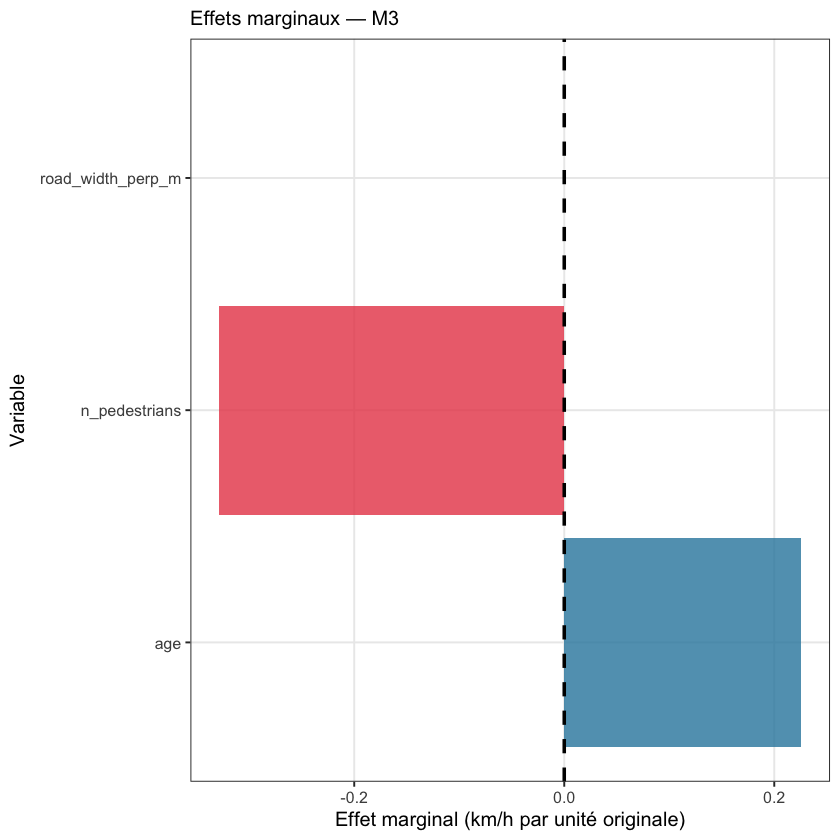

In [ ]:
coefs <- coef(r3$fit)
mu_val <- coefs["(Intercept)"]

var_map <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    unit = "piéton(s)"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", unit = "mètre(s)"),
  list(beta = "z_age",            raw = "age",              unit = "an(s)")
)

me_rows <- lapply(var_map, function(x) {
  beta_z      <- unname(coefs[x$beta])
  sd_raw      <- unname(stds_[x$raw])
  me_per_unit <- if (!is.na(beta_z) && !is.na(sd_raw)) beta_z / sd_raw else NA_real_
  data.frame(Variable          = x$raw,
             `beta_z (km/h/σ)` = round(beta_z, 4),
             `ME (km/h/unité)` = round(me_per_unit, 5),
             Unité              = x$unit,
             check.names = FALSE)
})

me_df <- bind_rows(me_rows)
cat("Effets marginaux — M3 :\n")
print(me_df)

ggplot(me_df, aes(x = `ME (km/h/unité)`, y = Variable,
                  fill = `ME (km/h/unité)` >= 0)) +
  geom_col(alpha = 0.8) +
  scale_fill_manual(values = c("TRUE" = COLOR_A, "FALSE" = COLOR_B), guide = "none") +
  geom_vline(xintercept = 0, linetype = "dashed", linewidth = 1) +
  labs(x = "Effet marginal (km/h par unité originale)",
       title = "Effets marginaux — M3") +
  theme(legend.position = "none")

## 9 · Courbes de prédiction (M3)

Chaque graphique fait varier **une variable** sur son étendue (p2–p98),
toutes les autres maintenues à leur moyenne (z = 0).

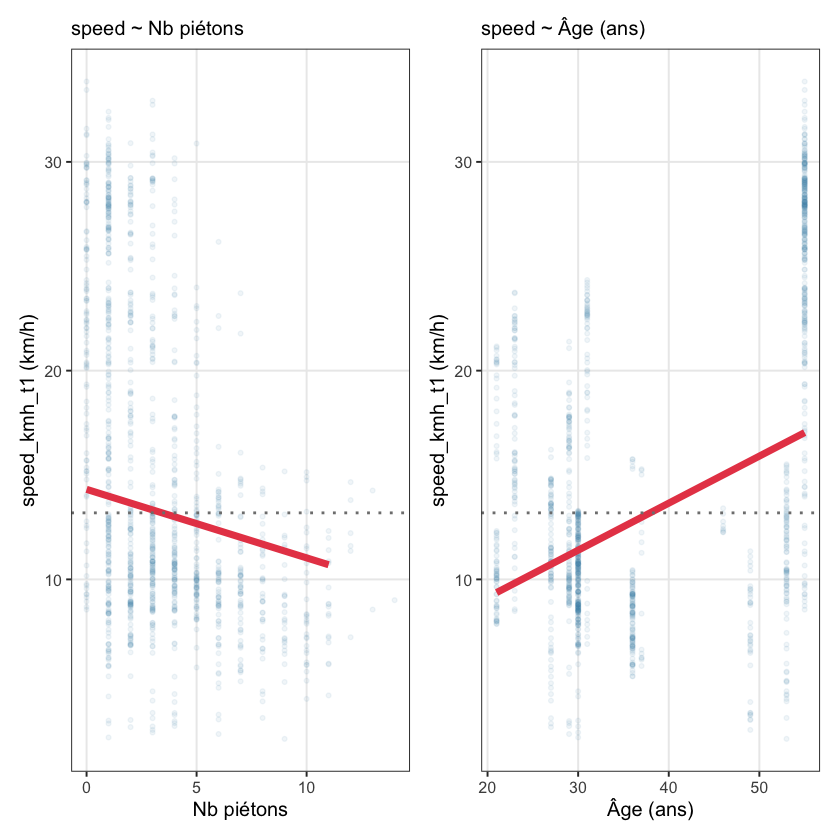

In [ ]:
vars_plot <- list(
  list(beta = "z_n_pedestrians",  raw = "n_pedestrians",    label = "Nb piétons"),
  list(beta = "z_road_width_perp_m", raw = "road_width_perp_m", label = "Largeur route (m)"),
  list(beta = "z_age",            raw = "age",              label = "Âge (ans)")
)

plots_pred <- lapply(vars_plot, function(v) {
  if (!(v$raw %in% names(df_model))) return(NULL)
  beta_val <- coefs[v$beta]
  if (is.na(beta_val)) return(NULL)

  x_raw <- seq(quantile(df_model[[v$raw]], 0.02, na.rm = TRUE),
               quantile(df_model[[v$raw]], 0.98, na.rm = TRUE),
               length.out = 200)
  x_z    <- (x_raw - means_[v$raw]) / stds_[v$raw]
  y_pred <- mu_val + beta_val * x_z

  pred_df  <- data.frame(x = x_raw, y = y_pred)
  obs_df   <- df_model[, c(v$raw, "speed_kmh_t1")] %>%
              rename(x = 1, y = speed_kmh_t1) %>%
              filter(!is.na(x), !is.na(y))

  ggplot() +
    geom_point(data = obs_df,  aes(x = x, y = y),
               alpha = 0.07, size = 1, color = COLOR_A) +
    geom_line(data  = pred_df, aes(x = x, y = y),
              color = COLOR_B, linewidth = 2) +
    geom_hline(yintercept = mu_val, linetype = "dotted",
               color = "gray50", linewidth = 0.8) +
    labs(x = v$label, y = "speed_kmh_t1 (km/h)",
         title = paste("speed ~", v$label))
})

plots_pred <- Filter(Negate(is.null), plots_pred)
wrap_plots(plots_pred, nrow = 1)

## 10 · Diagnostic des résidus (M3)

R² (OLS) — M3 : 0.5674
RMSE — M3      : 4.957 km/h



Test Shapiro-Wilk (n=1210) : stat=0.9806, p=1.2195e-11


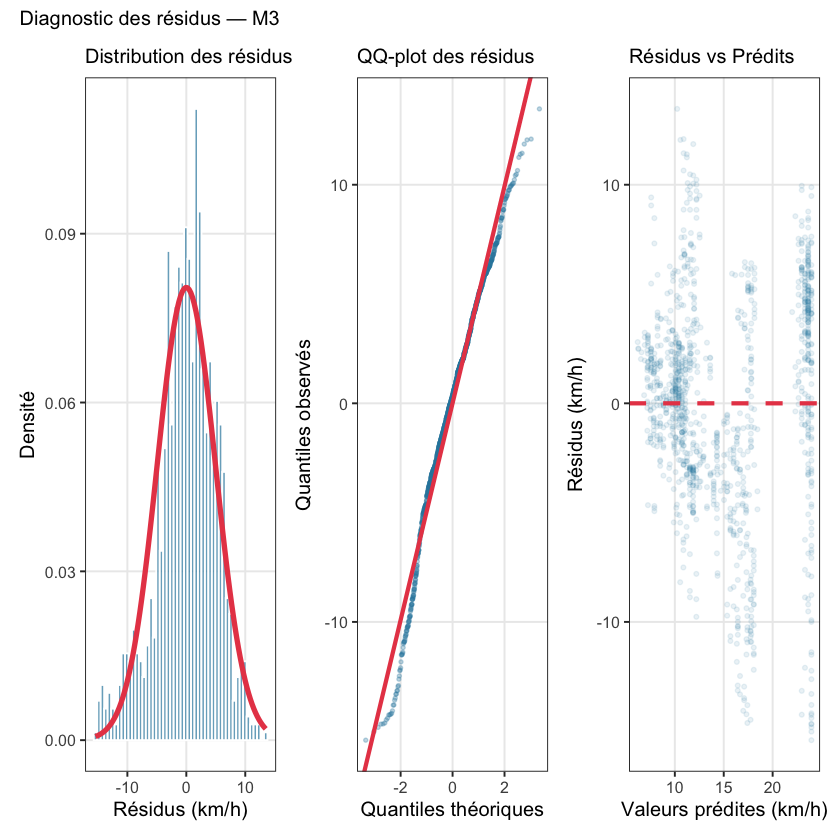

In [ ]:
data_m3 <- df_model %>%
  select(speed_kmh_t1, z_n_pedestrians, z_road_width_perp_m, z_age,
         genre, experience, time_of_day) %>%
  filter(complete.cases(.))

y_pred_m3 <- predict(r3$fit, newdata = data_m3)
residuals  <- data_m3$speed_kmh_t1 - y_pred_m3
rmse       <- sqrt(mean(residuals^2))

cat(sprintf("R²     — M3 : %.4f\n", r3$metrics$r2))
cat(sprintf("R²_adj — M3 : %.4f\n", r3$metrics$r2_adj))
cat(sprintf("RMSE   — M3 : %.3f km/h\n", rmse))

resid_df <- data.frame(y_pred = y_pred_m3, resid = residuals)

# 1. Distribution des résidus
p_hist <- ggplot(resid_df, aes(x = resid)) +
  geom_histogram(aes(y = after_stat(density)), bins = 50,
                 fill = COLOR_A, alpha = 0.7, color = "white") +
  stat_function(fun = dnorm, args = list(mean = 0, sd = sd(residuals)),
                color = COLOR_B, linewidth = 1.5) +
  labs(x = "Résidus (km/h)", y = "Densité", title = "Distribution des résidus")

# 2. QQ-plot
qq_data <- data.frame(
  sample    = sort(residuals),
  theorical = qnorm(ppoints(length(residuals)))
)
p_qq <- ggplot(qq_data, aes(x = theorical, y = sample)) +
  geom_point(alpha = 0.3, size = 0.8, color = COLOR_A) +
  geom_abline(slope = sd(residuals), intercept = 0,
              color = COLOR_B, linewidth = 1.2) +
  labs(x = "Quantiles théoriques", y = "Quantiles observés",
       title = "QQ-plot des résidus")

# 3. Résidus vs valeurs prédites
p_rv <- ggplot(resid_df, aes(x = y_pred, y = resid)) +
  geom_point(alpha = 0.1, size = 1, color = COLOR_A) +
  geom_hline(yintercept = 0, color = COLOR_B, linetype = "dashed", linewidth = 1.2) +
  labs(x = "Valeurs prédites (km/h)", y = "Résidus (km/h)",
       title = "Résidus vs Prédits")

(p_hist | p_qq | p_rv) +
  plot_annotation(title = "Diagnostic des résidus — M3")

# Test de normalité Shapiro-Wilk (sous-échantillon)
n_test    <- min(5000, length(residuals))
sw_result <- shapiro.test(sample(residuals, n_test))
cat(sprintf("\nTest Shapiro-Wilk (n=%d) : stat=%.4f, p=%.4e\n",
            n_test, sw_result$statistic, sw_result$p.value))

## 11 · Visualisation comparaison des modèles

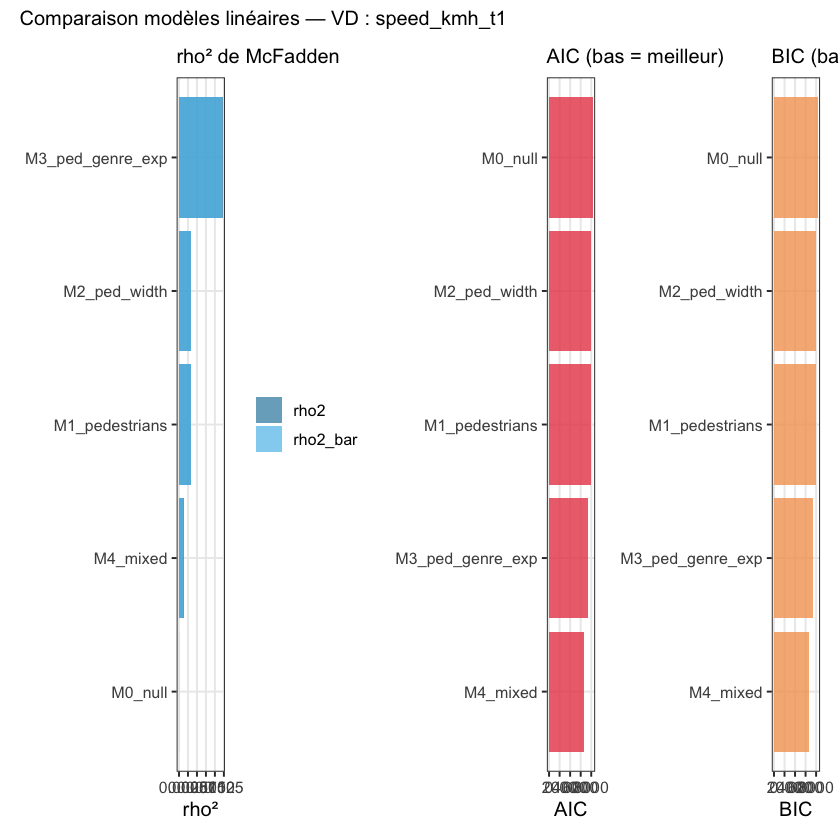

In [ ]:
p_rho <- comparison %>%
  select(Model, rho2, rho2_bar) %>%
  pivot_longer(-Model) %>%
  ggplot(aes(x = reorder(Model, value), y = value, fill = name)) +
  geom_col(position = "identity", alpha = 0.7) +
  scale_fill_manual(values = c("rho2" = COLOR_A, "rho2_bar" = "#5BC0EB")) +
  coord_flip() +
  labs(x = NULL, y = "rho²", title = "rho² de McFadden", fill = NULL)

# R² / Rm² / Rc² selon le type de modèle
r2_long <- comparison %>%
  select(Model, r2, r2_adj, r2_marginal, r2_conditional) %>%
  pivot_longer(-Model, names_to = "metric", values_to = "value") %>%
  filter(!is.na(value)) %>%
  mutate(metric = factor(metric,
    levels = c("r2", "r2_adj", "r2_marginal", "r2_conditional"),
    labels = c("R\u00b2", "R\u00b2_adj", "Rm\u00b2 (marginal)", "Rc\u00b2 (conditionnel)")))

p_r2 <- ggplot(r2_long, aes(x = reorder(Model, value), y = value, fill = metric)) +
  geom_col(position = "dodge", alpha = 0.85) +
  scale_fill_manual(values = c(
    "R\u00b2"               = COLOR_A,
    "R\u00b2_adj"           = "#5BC0EB",
    "Rm\u00b2 (marginal)"   = "#F4A261",
    "Rc\u00b2 (conditionnel)" = "#E84855"
  )) +
  coord_flip() +
  labs(x = NULL, y = "R\u00b2", title = "R\u00b2 (OLS) / Rm\u00b2 & Rc\u00b2 (mixte)", fill = NULL)

p_aic <- ggplot(comparison, aes(x = reorder(Model, AIC), y = AIC)) +
  geom_col(fill = COLOR_B, alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "AIC", title = "AIC (bas = meilleur)")

p_bic <- ggplot(comparison, aes(x = reorder(Model, BIC), y = BIC)) +
  geom_col(fill = "#F4A261", alpha = 0.8) +
  coord_flip() +
  labs(x = NULL, y = "BIC", title = "BIC (bas = meilleur)")

(p_rho | p_r2) / (p_aic | p_bic) +
  plot_annotation(title = "Comparaison modèles linéaires — VD : speed_kmh_t1")

## 12 · Synthèse
